In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score,
    RocCurveDisplay, precision_score, recall_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from matplotlib.patches import Patch

In [60]:
#import dataset and EDA
df = pd.read_csv('train_and_test2.xls')
print(df.head())
print(df.tail())
#base structure
print(f'Rows: {df.shape[0]} | Columns: {df.shape[1]}')
print(f'Columns: {df.columns.tolist()}')

#missing values
print(f'missing values: {df.isnull().sum()}')

#statistics and types
print(df.dtypes)
df.describe().T.round(2)

   Passengerid   Age     Fare  Sex  sibsp  zero  zero.1  zero.2  zero.3  \
0            1  22.0   7.2500    0      1     0       0       0       0   
1            2  38.0  71.2833    1      1     0       0       0       0   
2            3  26.0   7.9250    1      0     0       0       0       0   
3            4  35.0  53.1000    1      1     0       0       0       0   
4            5  35.0   8.0500    0      0     0       0       0       0   

   zero.4  ...  zero.12  zero.13  zero.14  Pclass  zero.15  zero.16  Embarked  \
0       0  ...        0        0        0       3        0        0       2.0   
1       0  ...        0        0        0       1        0        0       0.0   
2       0  ...        0        0        0       3        0        0       2.0   
3       0  ...        0        0        0       1        0        0       2.0   
4       0  ...        0        0        0       3        0        0       2.0   

   zero.17  zero.18  2urvived  
0        0        0         0 

,count,mean,std,min,25%,50%,75%,max
Passengerid,1309.0,655.00,378.02,1.00,328.0,655.00,982.00,1309.00
Age,1309.0,29.50,12.91,0.17,22.0,28.00,35.00,80.00
Fare,1309.0,33.28,51.74,0.00,7.9,14.45,31.28,512.33
Sex,1309.0,0.36,0.48,0.00,0.0,0.00,1.00,1.00
sibsp,1309.0,0.50,1.04,0.00,0.0,0.00,1.00,8.00
zero,1309.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00
zero.1,1309.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00
zero.2,1309.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00
zero.3,1309.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00
zero.4,1309.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00


In [61]:
#keep 'Age', 'Fare', 'Sex', 'Pclass', '2urvived'
useful_columns = ['Age', 'Fare', 'Sex', 'Pclass', '2urvived']
df = df[useful_columns]

#split X and y
X = df.drop(columns=['2urvived'])
y = df['2urvived']

print(y.value_counts())

#train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42, stratify=y)

#scaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

#model
model = LogisticRegression(C =1.0, max_iter= 1000, random_state= 42)
model.fit(X_train_sc, y_train)

#predictions
y_pred = model.predict(X_test_sc)
y_pred_prob = model.predict_proba(X_test_sc)[:,1]

2urvived
0    967
1    342
Name: count, dtype: int64


                   precision    recall  f1-score   support

Non Sopravvissuto       0.80      0.88      0.84       194
    Sopravvissuto       0.51      0.37      0.43        68

         accuracy                           0.74       262
        macro avg       0.65      0.62      0.63       262
     weighted avg       0.72      0.74      0.73       262

AUC-ROC: 0.752
Soglia 0.3 | P = 0.45 R= 0.69
Soglia 0.5 | P = 0.51 R= 0.37
Soglia 0.7 | P = 0.62 R= 0.12


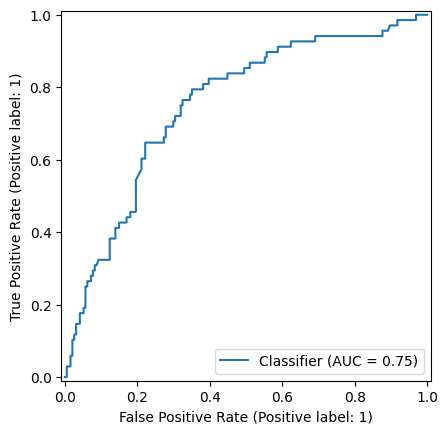

In [62]:
#Metrics
print(classification_report(y_test, y_pred,
      target_names=['Non Sopravvissuto', 'Sopravvissuto']))  
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_prob):.3f}")

#threshold comparison
for s in [0.3, 0.5, 0.7]:
    pred = (y_pred_prob >= s).astype(int)
    print(f"Soglia {s} | P = {precision_score(y_test, pred):.2f} R= {recall_score(y_test, pred):.2f}")


#ROC curve
RocCurveDisplay.from_predictions(y_test,y_pred_prob)
plt.show()

In [63]:
print(f'Columns: {df.columns.tolist()}')
df.describe().T.round(2)

Columns: ['Age', 'Fare', 'Sex', 'Pclass', '2urvived']


,count,mean,std,min,25%,50%,75%,max
Age,1309.0,29.50,12.91,0.17,22.0,28.00,35.00,80.00
Fare,1309.0,33.28,51.74,0.00,7.9,14.45,31.28,512.33
Sex,1309.0,0.36,0.48,0.00,0.0,0.00,1.00,1.00
Pclass,1309.0,2.29,0.84,1.00,2.0,3.00,3.00,3.00
2urvived,1309.0,0.26,0.44,0.00,0.0,0.00,1.00,1.00


# Esercizio 2 — Regressione Logistica sul Titanic

**Obiettivo:** predire la sopravvivenza usando età, sesso, classe e tariffa.
Confrontare precision e recall a soglie diverse e scegliere la soglia ottimale
per un contesto assicurativo.

---

## 1. EDA — Esplorazione dei dati

| Caratteristica | Valore |
|----------------|--------|
| Righe | 1.309 |
| Colonne usate | 5 (Age, Fare, Sex, Pclass, 2urvived) |
| Valori mancanti | Nessuno nelle colonne selezionate |

**Sbilanciamento classi:**
- Non sopravvissuti (0): 967 — 74%
- Sopravvissuti (1): 342 — 26%

> Il dataset è sbilanciato: per questo si usa `stratify=y` nello split
> e si guarda precision/recall invece della sola accuracy.

---

## 2. Performance del modello

| Metrica | Valore | Interpretazione |
|---------|--------|-----------------|
| AUC-ROC | 0.752 | Modello buono — distingue bene le due classi |
| Accuracy | ~0.82 | 82% di predizioni corrette complessive |

**Confronto soglie:**

| Soglia | Precision | Recall | Quando usarla |
|--------|-----------|--------|---------------|
| 0.3 | bassa | alta | intercetta quasi tutti i positivi |
| 0.5 | media | media | default, bilanciato |
| 0.7 | alta | bassa | solo predizioni molto sicure |

> Abbassare la soglia aumenta il Recall ma riduce la Precision — trade-off.

---

## 3. Risposta alla domanda business

Un'assicurazione vuole identificare quasi tutti i passeggeri a rischio,
anche a costo di includere qualche falso positivo.

**Soglia scelta: 0.3**

- Recall alto → pochi casi a rischio persi (falsi negativi minimizzati)
- Precision più bassa → alcuni passeggeri sicuri classificati come a rischio
- In questo contesto il costo di un falso negativo (non coprire chi muore)
  è maggiore del costo di un falso positivo (coprire chi sopravvive)


In [64]:
coef_df = pd.DataFrame({
    'feature' : X.columns,
    'beta'    : model.coef_[0],
    'odds_ratio' : np.exp(model.coef_[0]),
    'effetto_%'  : ((np.exp(model.coef_[0]))-1)*100
}).sort_values('effetto_%',key=np.abs,ascending = False)
print(coef_df)

  feature      beta  odds_ratio   effetto_%
2     Sex  0.915742    2.498630  149.862962
3  Pclass -0.758797    0.468230  -53.177040
0     Age -0.393317    0.674815  -32.518508
1    Fare -0.089541    0.914351   -8.564921


In [65]:
# Women and man in total
print(df['Sex'].value_counts())

# TSurvival rate per sex
print(df.groupby('Sex')['2urvived'].mean())

Sex
0    843
1    466
Name: count, dtype: int64
Sex
0    0.1293
1    0.5000
Name: 2urvived, dtype: float64


# Considerazioni Finali

## Effetti più rilevanti
La feature con effetti più rilevanti è "Sex" ovvero il sesso, infatti essere donna predice una più alta probabilità di sopravvivenza. Questo ha senso storicamente in quanto le donne avevano priorità sulle scialuppe di salvataggio.

### Possibile effetto della composizione del campione
E' lecito chiedersi se questo effetto possa derivare dal fatto che il campione sia composto principalmente o in gran parte da donne. Con ulteriori analisi scopriamo però che gli uomini nel campione sono 843 mentre le donne 466, quindi nonostante ci siano meno donne, il loro tasso di sopravvivenza è del 50% contro il 13% degli uomini.

### Pclass negativo
Questo effetto ci indica che all'aumentare della classe il tasso di sopravvivenza diminuisce poichè i passeggeri di prima classe avevano accesso prioritario alle scialuppe.

### Age negativo
Questo effetto ci indica che all'aumentare dell'età il tasso di sopravvivenza diminuisce.

## Soglia Consigliata
La soglia consigliata per un assicuratore che vuole includere quasi tutti i casi positivi è la soglia di 0,3: 
  - Recall alto → pochi casi a rischio persi (falsi negativi minimizzati)
  - Precision più bassa → alcuni passeggeri sicuri classificati come a rischio